# Loan Approval Prediction - Live Demo
**COEN 330 - Applied Machine Learning**

This notebook loads the final trained pipeline and estimates whether a new application resembles **historically approved** or **historically rejected** applications. Based on that, it makes prediction if the new applicant's loan is going to be approved or rejected.

This demo also runs the **same applicant profiles** through two trained Gradient Boosting pipelines:

1. A model trained **with** `previous_loan_defaults_on_file`.
2. A model trained **without** `previous_loan_defaults_on_file`.

The comparison shows whether removing the previous-default feature changes the estimated approval probability or the final approval/rejection prediction.

## Step 1 - Load the trained pipelines

Required files:

- `models/GradientBoosting.pkl`: final model, trained **with** `previous_loan_defaults_on_file`
- `models/GradientBoosting_WITHOUT_prevdef.pkl`: same algorithm, trained **without** it
- `results/test_results.csv` and `results/feature_set_test_results.csv`: supply the F1-tuned decision thresholds

Each `.pkl` holds the complete fitted pipeline (preprocessing + classifier)

In [2]:
import sys, os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

sys.path.insert(0, os.path.abspath("../src"))

import preprocessing 
from utils import MODELS_DIR, RESULTS_DIR, PLOTS_DIR

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_FILES = {
    "with_prevdef": "GradientBoosting.pkl",
    "without_prevdef": "GradientBoosting_WITHOUT_prevdef.pkl",
}

pipeline_with_prevdef = joblib.load(MODELS_DIR / MODEL_FILES["with_prevdef"])
pipeline_without_prevdef = joblib.load(MODELS_DIR / MODEL_FILES["without_prevdef"])

print("Loaded models:")
print(f"  With previous-default feature   : {MODEL_FILES['with_prevdef']}")
print(f"  Without previous-default feature: {MODEL_FILES['without_prevdef']}")
print("\nPipeline steps:")
print(f"  With feature   : {list(pipeline_with_prevdef.named_steps)}")
print(f"  Without feature: {list(pipeline_without_prevdef.named_steps)}")

Loaded models:
  With previous-default feature   : GradientBoosting.pkl
  Without previous-default feature: GradientBoosting_WITHOUT_prevdef.pkl

Pipeline steps:
  With feature   : ['pre', 'clf']
  Without feature: ['pre', 'clf']


## Step 2 - Define three applicant profiles

The exact same three applicant values are used for both models.  
`loan_percent_income` is calculated automatically so the inputs stay internally consistent.

In [3]:
applicant_a = {
    "person_age": 29,
    "person_gender": "male",
    "person_education": "Bachelor",
    "person_income": 55_000,
    "person_emp_exp": 4,
    "person_home_ownership": "RENT",
    "loan_amnt": 12_000,
    "loan_intent": "EDUCATION",
    "loan_int_rate": 11.5,
    "cb_person_cred_hist_length": 5,
    "credit_score": 640,
    "previous_loan_defaults_on_file": "No",
}

applicant_b = {
    "person_age": 22,
    "person_gender": "female",
    "person_education": "High School",
    "person_income": 18_000,
    "person_emp_exp": 0,
    "person_home_ownership": "RENT",
    "loan_amnt": 14_000,
    "loan_intent": "PERSONAL",
    "loan_int_rate": 18.5,
    "cb_person_cred_hist_length": 2,
    "credit_score": 480,
    "previous_loan_defaults_on_file": "No",
}

applicant_c = {
    "person_age": 27,
    "person_gender": "female",
    "person_education": "Doctorate",
    "person_income": 90_000,
    "person_emp_exp": 8,
    "person_home_ownership": "RENT",
    "loan_amnt": 5_000,
    "loan_intent": "MEDICAL",
    "loan_int_rate": 7.5,
    "cb_person_cred_hist_length": 9,
    "credit_score": 810,
    "previous_loan_defaults_on_file": "Yes",
}


APPLICANTS = {
    "Applicant A": applicant_a,
    "Applicant B": applicant_b,
    "Applicant C": applicant_c,
}


for applicant in APPLICANTS.values():
    applicant["loan_percent_income"] = (
        applicant["loan_amnt"] / applicant["person_income"]
    )


applicant_overview = pd.DataFrame.from_dict(
    APPLICANTS,
    orient="index",
)

display(applicant_overview)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_percent_income
Applicant A,29,male,Bachelor,55000,4,RENT,12000,EDUCATION,11.5,5,640,No,0.218182
Applicant B,22,female,High School,18000,0,RENT,14000,PERSONAL,18.5,2,480,No,0.777778
Applicant C,27,female,Doctorate,90000,8,RENT,5000,MEDICAL,7.5,9,810,Yes,0.055556


## Step 3 - Run each applicant through both models

The reduced model receives all the same applicant information as the base model except that the previous-default column is removed before prediction, matching the feature set used during its training.

In [ ]:
FALLBACK_THRESHOLD = 0.50
PREV_DEFAULT_COLUMN = "previous_loan_defaults_on_file"
GB_MODEL_NAME = "Gradient Boosting"


def _load_threshold(csv_path, filters, fallback=FALLBACK_THRESHOLD):
    """
    Read the Gradient Boosting models' F1-tuned decision threshold from 04_evaluation result CSV.
    Falls back to 0.50 if the file or matching row is missing.
    """
    try:
        df = pd.read_csv(csv_path)
        for col, val in filters.items():
            df = df[df[col] == val]
        return float(df["Threshold"].iloc[0])
    except (FileNotFoundError, IndexError, KeyError):
        return fallback

THRESHOLDS = {
    "with_prevdef": _load_threshold(
        RESULTS_DIR / "test_results.csv",
        {"Model": GB_MODEL_NAME},
    ),
    "without_prevdef": _load_threshold(
        RESULTS_DIR / "feature_set_test_results.csv",
        {"Model": GB_MODEL_NAME, "Feature Set": "WITHOUT_prevdef"},
    ),
}

print("Decision thresholds (F1-tuned in 04_evaluation):")
print(f"  With feature   : {THRESHOLDS['with_prevdef']:.4f}")
print(f"  Without feature: {THRESHOLDS['without_prevdef']:.4f}")


def predict_applicant(applicant, model_pipeline, *, uses_prevdef, threshold):
    """Predict one applicant using a complete saved pipeline at the given threshold."""
    X_new = pd.DataFrame([applicant])
    if not uses_prevdef:
        X_new = X_new.drop(columns=[PREV_DEFAULT_COLUMN], errors="ignore")

    if not hasattr(model_pipeline, "predict_proba"):
        raise TypeError("This demo expects the model to provide predict_proba().")

    probability = float(model_pipeline.predict_proba(X_new)[0, 1])
    decision = "APPROVED" if probability >= threshold else "REJECTED"
    return {"decision": decision, "approval_probability": probability, "threshold": threshold}


def compare_models(applicant, profile_name):
    """Run one applicant through both pipelines, each at its own tuned threshold."""
    result_with = predict_applicant(
        applicant, pipeline_with_prevdef,
        uses_prevdef=True, threshold=THRESHOLDS["with_prevdef"],
    )
    result_without = predict_applicant(
        applicant, pipeline_without_prevdef,
        uses_prevdef=False, threshold=THRESHOLDS["without_prevdef"],
    )
    return {
        "Profile": profile_name,
        "Previous defaults": applicant[PREV_DEFAULT_COLUMN],
        "With feature P(Approved)": result_with["approval_probability"],
        "With feature Decision": result_with["decision"],
        "Without feature P(Approved)": result_without["approval_probability"],
        "Without feature Decision": result_without["decision"],
        "Probability difference (with - without)": (
            result_with["approval_probability"] - result_without["approval_probability"]
        ),
        "Decision changed?": result_with["decision"] != result_without["decision"],
    }


comparison = pd.DataFrame([
    compare_models(applicant, profile_name)
    for profile_name, applicant in APPLICANTS.items()
])

display(
    comparison.style.format({
        "With feature P(Approved)": "{:.1%}",
        "Without feature P(Approved)": "{:.1%}",
        "Probability difference (with - without)": "{:+.1%}",
    })
)

n_changed = int(comparison["Decision changed?"].sum())
print(f"\nRemoving the feature flipped the decision for {n_changed} of {len(comparison)} applicants "
      f"(each model at its own tuned threshold).")

comparison_path = RESULTS_DIR / "demo_model_feature_comparison.csv"
comparison.to_csv(comparison_path, index=False)
print(f"Saved comparison table: {comparison_path}")

Decision thresholds (F1-tuned in 04_evaluation):
  With feature   : 0.4147
  Without feature: 0.4214


,Profile,Previous defaults,With feature P(Approved),With feature Decision,Without feature P(Approved),Without feature Decision,Probability difference (with - without),Decision changed?
0,Applicant A,No,20.4%,REJECTED,11.3%,REJECTED,+9.1%,False
1,Applicant B,No,100.0%,APPROVED,99.9%,APPROVED,+0.1%,False
2,Applicant C,Yes,0.0%,REJECTED,9.4%,REJECTED,-9.4%,False



Removing the feature flipped the decision for 0 of 3 applicants (each model at its own tuned threshold).
Saved comparison table: D:\Concordia Courses\Summer 2026\COEN 330\COEN 330 Project\COEN330-Machine-Learning-Project\results\demo_model_feature_comparison.csv


## Step 4 - Visual Comparison


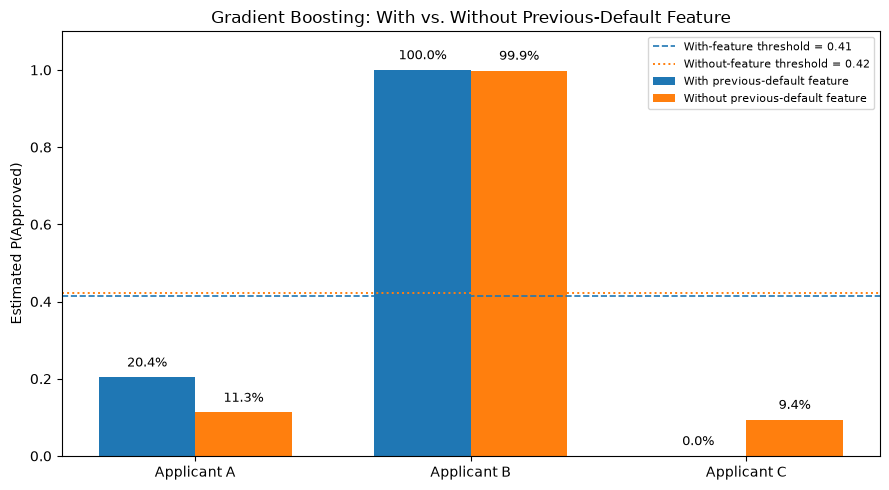

Saved plot: D:\Concordia Courses\Summer 2026\COEN 330\COEN 330 Project\COEN330-Machine-Learning-Project\results\plots\demo_with_vs_without_previous_defaults.png


In [7]:
profiles = comparison["Profile"].tolist()
with_probabilities = comparison["With feature P(Approved)"].to_numpy()
without_probabilities = comparison["Without feature P(Approved)"].to_numpy()

x = np.arange(len(profiles))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_with = ax.bar(x - width / 2, with_probabilities, width,
                   label="With previous-default feature")
bars_without = ax.bar(x + width / 2, without_probabilities, width,
                      label="Without previous-default feature")

# Each model's own tuned decision threshold
ax.axhline(THRESHOLDS["with_prevdef"], color=bars_with[0].get_facecolor(),
           linestyle="--", linewidth=1.2,
           label=f"With-feature threshold = {THRESHOLDS['with_prevdef']:.2f}")
ax.axhline(THRESHOLDS["without_prevdef"], color=bars_without[0].get_facecolor(),
           linestyle=":", linewidth=1.4,
           label=f"Without-feature threshold = {THRESHOLDS['without_prevdef']:.2f}")

for bars in (bars_with, bars_without):
    for bar in bars:
        p = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, p + 0.02, f"{p:.1%}",
                ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(profiles)
ax.set_ylim(0, 1.10)
ax.set_ylabel("Estimated P(Approved)")
ax.set_title("Gradient Boosting: With vs. Without Previous-Default Feature")
ax.legend(fontsize=8)
plt.tight_layout()

plot_path = PLOTS_DIR / "demo_with_vs_without_previous_defaults.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved plot: {plot_path}")

### Interpretation

Including `previous_loan_defaults_on_file` shifts each applicant's estimated approval probability upward for those with no prior loan defaults, downward for those with them, while the rest of the profile is identical. The bar chart plots these probabilities against **each model's own tuned threshold**, and the `Decision changed?` column (with the count printed above) flags where a shift actually crosses the decision boundary. Probability movement without a decision change still matters: it reflects how much confidence the feature carries, consistent with the dominant role it showed in `04_evaluation`.

## Step 5 - Counterfactual previous-default test

For each applicant, every value is held constant while only  
`previous_loan_defaults_on_file` is changed from `"No"` to `"Yes"`.

Expected behavior:

- The model trained **with** the feature may change its probability or decision.
- The model trained **without** the feature should remain unchanged because that field is removed before prediction.


In [9]:
def previous_default_counterfactual(applicant, profile_name):
    """Hold everything constant, toggle only previous-default history, compare both models."""
    applicant_no = {**applicant, PREV_DEFAULT_COLUMN: "No"}
    applicant_yes = {**applicant, PREV_DEFAULT_COLUMN: "Yes"}

    with_no = predict_applicant(applicant_no, pipeline_with_prevdef,
                                uses_prevdef=True, threshold=THRESHOLDS["with_prevdef"])
    with_yes = predict_applicant(applicant_yes, pipeline_with_prevdef,
                                 uses_prevdef=True, threshold=THRESHOLDS["with_prevdef"])
    without_no = predict_applicant(applicant_no, pipeline_without_prevdef,
                                   uses_prevdef=False, threshold=THRESHOLDS["without_prevdef"])
    without_yes = predict_applicant(applicant_yes, pipeline_without_prevdef,
                                    uses_prevdef=False, threshold=THRESHOLDS["without_prevdef"])

    return {
        "Profile": profile_name,
        "With feature P(No defaults)": with_no["approval_probability"],
        "With feature P(Yes defaults)": with_yes["approval_probability"],
        "With feature delta (Yes - No)": with_yes["approval_probability"] - with_no["approval_probability"],
        "With feature Decision (No -> Yes)": f"{with_no['decision']} -> {with_yes['decision']}",
        "With feature decision flipped?": with_no["decision"] != with_yes["decision"],
        "Without feature P(No defaults)": without_no["approval_probability"],
        "Without feature P(Yes defaults)": without_yes["approval_probability"],
        "Without feature delta (Yes - No)": without_yes["approval_probability"] - without_no["approval_probability"],
        "Without feature Decision (No -> Yes)": f"{without_no['decision']} -> {without_yes['decision']}",
    }


counterfactual_comparison = pd.DataFrame([
    previous_default_counterfactual(applicant, profile_name)
    for profile_name, applicant in APPLICANTS.items()
])

display(
    counterfactual_comparison.style.format({
        "With feature P(No defaults)": "{:.1%}",
        "With feature P(Yes defaults)": "{:.1%}",
        "With feature delta (Yes - No)": "{:+.1%}",
        "Without feature P(No defaults)": "{:.1%}",
        "Without feature P(Yes defaults)": "{:.1%}",
        "Without feature delta (Yes - No)": "{:+.1%}",
    })
)

without_max_swing = counterfactual_comparison["Without feature delta (Yes - No)"].abs().max()
print(f"\nWithout-feature model: max probability swing from the toggle = {without_max_swing:+.1%} "
      f"(should be 0.0% because the column is dropped before prediction).")

counterfactual_path = RESULTS_DIR / "demo_previous_default_counterfactual.csv"
counterfactual_comparison.to_csv(counterfactual_path, index=False)
print(f"Saved counterfactual table: {counterfactual_path}")

,Profile,With feature P(No defaults),With feature P(Yes defaults),With feature delta (Yes - No),With feature Decision (No -> Yes),With feature decision flipped?,Without feature P(No defaults),Without feature P(Yes defaults),Without feature delta (Yes - No),Without feature Decision (No -> Yes)
0,Applicant A,20.4%,0.0%,-20.4%,REJECTED -> REJECTED,False,11.3%,11.3%,+0.0%,REJECTED -> REJECTED
1,Applicant B,100.0%,0.1%,-99.9%,APPROVED -> REJECTED,True,99.9%,99.9%,+0.0%,APPROVED -> APPROVED
2,Applicant C,36.1%,0.0%,-36.1%,REJECTED -> REJECTED,False,9.4%,9.4%,+0.0%,REJECTED -> REJECTED



Without-feature model: max probability swing from the toggle = +0.0% (should be 0.0% because the column is dropped before prediction).
Saved counterfactual table: D:\Concordia Courses\Summer 2026\COEN 330\COEN 330 Project\COEN330-Machine-Learning-Project\results\demo_previous_default_counterfactual.csv


### Counterfactual Interpretation

Flipping only `previous_loan_defaults_on_file` from **No** to **Yes** sharply lowers the approval probability in the model that uses it.The `With feature delta` column is strongly negative for every applicant, and where it crosses the threshold the decision flips to **REJECTED**. The model trained without the feature is unaffected (its swing is 0.0% by construction, as printed above), confirming it ignores default history entirely. This is strong evidence of the feature's influence, though it shows association, not causation.

## Presentation takeaway

We evaluated the same applicants using two Gradient Boosting pipelines. The first model included previous-loan-default history, while the second excluded it. We compared approval probabilities and decisions, then performed a counterfactual test in which only the previous-default value was changed. The reduced model remained unchanged by design, while the base model performance indicates that it learned an association between previous-default history and historical loan approvals.
